# STAtten Training Run Analyzer
Place this notebook in your `output/train/` folder alongside the run directories.

In [4]:
# Import needed libraries

import os
import re
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from IPython.display import display, clear_output

In [5]:
# Discover run folders (folders containing args.yaml and sdt.log)
# These folders are generated during model training runs, training checkpoints are not needed

# Function definition that obtains all runs for given directory
# Must be run inside folder containing run results
def find_runs(base_dir="."):
    """Find all subdirectories that contain both args.yaml and a .log file."""
    runs = []
    for entry in sorted(os.listdir(base_dir)):
        path = os.path.join(base_dir, entry)
        if not os.path.isdir(path):
            continue
        has_args = os.path.exists(os.path.join(path, "args.yaml"))
        logs = [f for f in os.listdir(path) if f.endswith(".log")]
        if has_args and logs:
            runs.append(entry)
    return runs

# Function call to store and display all runs
runs = find_runs(".")
print(f"Found {len(runs)} run(s):")
for r in runs:
    print(f"  {r}")

Found 8 run(s):
  20260416-093931-sdt-data-cifar10-t-4-spike-lif
  20260417-165418-sdt-data-cifar10-t-4-spike-lif
  20260418-214255-sdt-data-cifar10-t-4-spike-plif
  20260420-070247-sdt-data-cifar10-t-4-spike-plif
  20260421-193325-sdt-data-cifar10-t-4-spike-lif
  20260422-165447-sdt-data-cifar10-t-4-spike-lif
  20260423-095450-sdt-data-cifar10-t-4-spike-plif
  20260424-072959-sdt-data-cifar10-t-4-spike-plif


In [6]:
# Load meta-data from each run folder

# Function definition that loads the argument yaml file from a run folder
def load_args(run_dir):
    with open(os.path.join(run_dir, "args.yaml")) as f:
        return yaml.safe_load(f)

# Function definition that loads the output log file from a run folder
def load_log(run_dir):
    """Parse the .log file and return two DataFrames: train_df and test_df."""
    logs = [f for f in os.listdir(run_dir) if f.endswith(".log")]
    log_path = os.path.join(run_dir, logs[0])

    train_rows = []
    test_rows  = []

    # Patterns
    # Train summary line: ends with LR value (last batch of epoch)
    train_pat = re.compile(
        r'Train:\s+(\d+)\s+\[\s*\d+/\d+.*?\].*?'
        r'Loss:\s+([\d.]+)\s+\(([\d.]+)\).*?'
        r'LR:\s+([\d.e+-]+)'
    )
    # Test summary line: the final [156/156] line with epoch-level averages
    test_pat = re.compile(
        r'Test:\s+\[\s*156/156\].*?'
        r'Loss:\s+[\d.]+\s+\(([\d.]+)\).*?'
        r'Acc@1:\s+[\d.]+\s+\(([\d.]+)\).*?'
        r'Acc@5:\s+[\d.]+\s+\(([\d.]+)\)'
    )
    # Best metric line to extract epoch
    best_pat = re.compile(r'Best metric:\s+([\d.]+)\s+\(epoch\s+(\d+)\)')

    current_epoch = None

    with open(log_path) as f:
        for line in f:
            # Track current epoch from train lines
            tm = train_pat.search(line)
            if tm:
                current_epoch = int(tm.group(1))
                train_rows.append({
                    "epoch": current_epoch,
                    "batch_loss": float(tm.group(2)),
                    "avg_loss":   float(tm.group(3)),
                    "lr":         float(tm.group(4)),
                })
                continue

            tsm = test_pat.search(line)
            if tsm and current_epoch is not None:
                test_rows.append({
                    "epoch": current_epoch,
                    "loss":  float(tsm.group(1)),
                    "acc1":  float(tsm.group(2)),
                    "acc5":  float(tsm.group(3)),
                })
                continue

    train_df = pd.DataFrame(train_rows)
    test_df  = pd.DataFrame(test_rows).drop_duplicates(subset="epoch", keep="last")
    return train_df, test_df

In [7]:
# Build / refresh CSVs for ALL runs
# Creates ./data/ and writes one train_summary.csv + test_summary.csv per run.
# Re-running this cell refreshes everything (old files are overwritten).

# Defines the /data directory inside the runs folder
# This is where the CSV tables for each run will be saved
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# For each run found above, process the log file and produce a CSV
for run_name in runs:
    train_df, test_df = load_log(run_name)

    if train_df.empty and test_df.empty:
        print(f"  SKIP {run_name} — no log data found")
        continue

    # One row per epoch (last batch entry = end-of-epoch averages)
    train_epoch_df = (
        train_df.groupby("epoch")
        .last()
        .reset_index()[["epoch", "avg_loss", "lr"]]
        .rename(columns={"avg_loss": "train_loss"})
    )

    # Save using run name as prefix so files don't collide
    # e.g. data/20260504-175246-sdt_train.csv
    safe_name = run_name.replace("/", "_").replace("\\", "_")
    train_csv = os.path.join(DATA_DIR, f"{safe_name}_train.csv")
    test_csv  = os.path.join(DATA_DIR, f"{safe_name}_test.csv")

    train_epoch_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    args = load_args(run_name)
    print(f"  OK  {run_name}")
    print(f"      attention={args.get('attention_mode','?')}  spike={args.get('spike_mode','?')}  epochs_completed={test_df['epoch'].max()+1 if not test_df.empty else 0}")
    print(f"      -> {train_csv}")
    print(f"      -> {test_csv}")

print(f"\nDone. {len(runs)} run(s) processed → {DATA_DIR}/")

  OK  20260416-093931-sdt-data-cifar10-t-4-spike-lif
      attention=STAtten  spike=lif  epochs_completed=210
      -> ./data\20260416-093931-sdt-data-cifar10-t-4-spike-lif_train.csv
      -> ./data\20260416-093931-sdt-data-cifar10-t-4-spike-lif_test.csv
  OK  20260417-165418-sdt-data-cifar10-t-4-spike-lif
      attention=SDT  spike=lif  epochs_completed=210
      -> ./data\20260417-165418-sdt-data-cifar10-t-4-spike-lif_train.csv
      -> ./data\20260417-165418-sdt-data-cifar10-t-4-spike-lif_test.csv
  OK  20260418-214255-sdt-data-cifar10-t-4-spike-plif
      attention=STAtten  spike=plif  epochs_completed=210
      -> ./data\20260418-214255-sdt-data-cifar10-t-4-spike-plif_train.csv
      -> ./data\20260418-214255-sdt-data-cifar10-t-4-spike-plif_test.csv
  OK  20260420-070247-sdt-data-cifar10-t-4-spike-plif
      attention=SDT  spike=plif  epochs_completed=210
      -> ./data\20260420-070247-sdt-data-cifar10-t-4-spike-plif_train.csv
      -> ./data\20260420-070247-sdt-data-cifar10-t-4-

Saved: ./data\comparison_all_runs.png


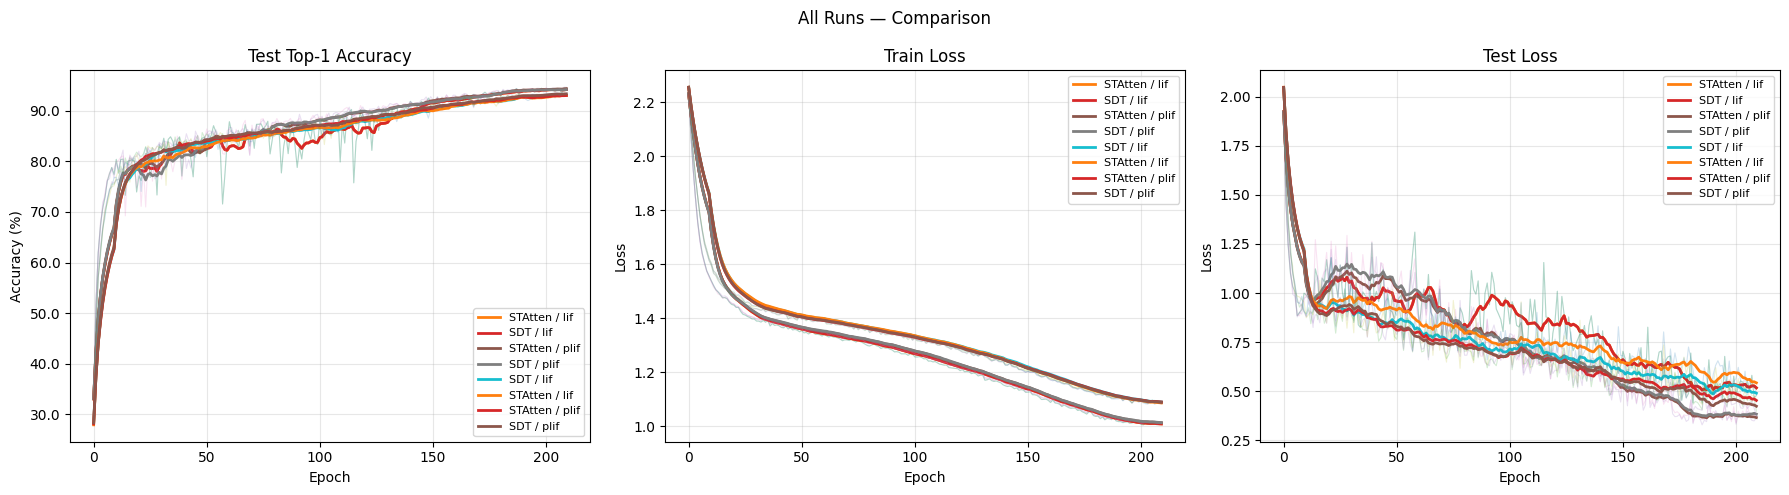

In [8]:
# Comparison plots across ALL runs
# Reads from the already-built CSVs in data/ and overlays all runs on shared axes.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("All Runs — Comparison", fontsize=12)

ax_acc   = axes[0]  # Top-1 accuracy
ax_tloss = axes[1]  # Train loss
ax_vloss = axes[2]  # Test loss

# For each run found above, generate a trace name and add data to the plots
for run_name in runs:
    safe_name = run_name.replace("/", "_").replace("\\", "_")
    train_csv = os.path.join(DATA_DIR, f"{safe_name}_train.csv")
    test_csv  = os.path.join(DATA_DIR, f"{safe_name}_test.csv")

    if not os.path.exists(train_csv) or not os.path.exists(test_csv):
        print(f"  SKIP {run_name} — CSVs missing, run the builder cell first")
        continue

    train_df = pd.read_csv(train_csv)
    test_df  = pd.read_csv(test_csv)
    merged   = pd.merge(train_df, test_df, on="epoch", how="outer").sort_values("epoch")

    # Build a short human-readable label from args
    args  = load_args(run_name)
    label = f"{args.get('attention_mode','?')} / {args.get('spike_mode','?')}"

    # Moving averages so overlapping lines are readable
    acc_ma   = test_df["acc1"].rolling(window=10, min_periods=1).mean()
    vloss_ma = test_df["loss"].rolling(window=10, min_periods=1).mean()
    tloss_ma = train_df["train_loss"].rolling(window=10, min_periods=1).mean()

    # Raw lines faded, MA bold
    ax_acc.plot(test_df["epoch"],  test_df["acc1"],    alpha=0.2, linewidth=0.8)
    ax_acc.plot(test_df["epoch"],  acc_ma,             linewidth=2.0, label=label)

    ax_tloss.plot(train_df["epoch"], train_df["train_loss"], alpha=0.2, linewidth=0.8)
    ax_tloss.plot(train_df["epoch"], tloss_ma,               linewidth=2.0, label=label)

    ax_vloss.plot(test_df["epoch"],  test_df["loss"],   alpha=0.2, linewidth=0.8)
    ax_vloss.plot(test_df["epoch"],  vloss_ma,          linewidth=2.0, label=label)

# After all data is generated for each plot, all graphs are initialized with reasonable settings
# This produces three plots, Test Top-1 Accuracy, Train Loss, and Test Loss per Epoch
ax_acc.set_title("Test Top-1 Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy (%)")
ax_acc.legend(fontsize=8)
ax_acc.grid(True, alpha=0.3)
ax_acc.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

ax_tloss.set_title("Train Loss")
ax_tloss.set_xlabel("Epoch")
ax_tloss.set_ylabel("Loss")
ax_tloss.legend(fontsize=8)
ax_tloss.grid(True, alpha=0.3)

ax_vloss.set_title("Test Loss")
ax_vloss.set_xlabel("Epoch")
ax_vloss.set_ylabel("Loss")
ax_vloss.legend(fontsize=8)
ax_vloss.grid(True, alpha=0.3)

plt.tight_layout()

comparison_path = os.path.join(DATA_DIR, "comparison_all_runs.png")
plt.savefig(comparison_path, dpi=150, bbox_inches="tight")
print(f"Saved: {comparison_path}")
plt.show()

In [9]:
# Run selector widget and show related values for each run

# This list shows all values from the arguments yaml to display for any run selected
KEYS_TO_SHOW = [
    ("Attention Mode",  "attention_mode"),
    ("Dataset",         "dataset"),
    ("Spike Mode",      "spike_mode"),
    ("Dim",             "dim"),
    ("Time Steps",      "time_steps"),
    ("Chunk Size",      "chunk_size"),
    ("Epochs",          "epochs"),
    ("Batch Size",      "batch_size"),
    ("Learning Rate",   "lr"),
    ("Num Heads",       "num_heads"),
    ("Layers",          "layer"),
]

# Produces a widget named selector with options named after elements in runs = [...]
# This should list the name(s) of each detected 'run folder' found in the second module
selector = widgets.Select(
    options=runs,
    description="Run:",
    layout=widgets.Layout(width="700px", height="160px"),
    style={"description_width": "50px"},
)

# Stores output data called for in "KEYS_TO_SHOW" for the selected widget item
info_out = widgets.Output()

# Function definition that defines widget selection behavior
def on_select(change):
    with info_out:
        clear_output(wait=True)
        run_name = change["new"]
        if not run_name:
            return
        args = load_args(run_name)

        print(f"\n{'─'*50}")
        print(f"  Run: {run_name}")
        print(f"{'─'*50}")
        for label, key in KEYS_TO_SHOW:
            val = args.get(key, "—")
            print(f"  {label:<20} {val}")
        print(f"{'─'*50}\n")

        # Sanity Check: how many epochs completed?
        _, test_df = load_log(run_name)
        if not test_df.empty:
            best_acc  = test_df["acc1"].max()
            best_ep   = test_df.loc[test_df["acc1"].idxmax(), "epoch"]
            last_ep   = test_df["epoch"].max()
            print(f"  Epochs completed : {last_ep + 1} / {args.get('epochs', '?')}")
            print(f"  Best Top-1 Acc   : {best_acc:.2f}%  (epoch {best_ep})")
            print(f"  Last Top-1 Acc   : {test_df.iloc[-1]['acc1']:.2f}%")
        else:
            print("  No test results found yet.")

# Function call that defines widget selection behavior
selector.observe(on_select, names="value")

# Outputs the produced widget and its output information at the bottom of the module 
display(widgets.VBox([selector, info_out]))

# Trigger initial display
if runs:
    selector.value = runs[0]
    on_select({"new": runs[0]})

Saved: ./data\20260416-093931-sdt-data-cifar10-t-4-spike-lif_plots.png


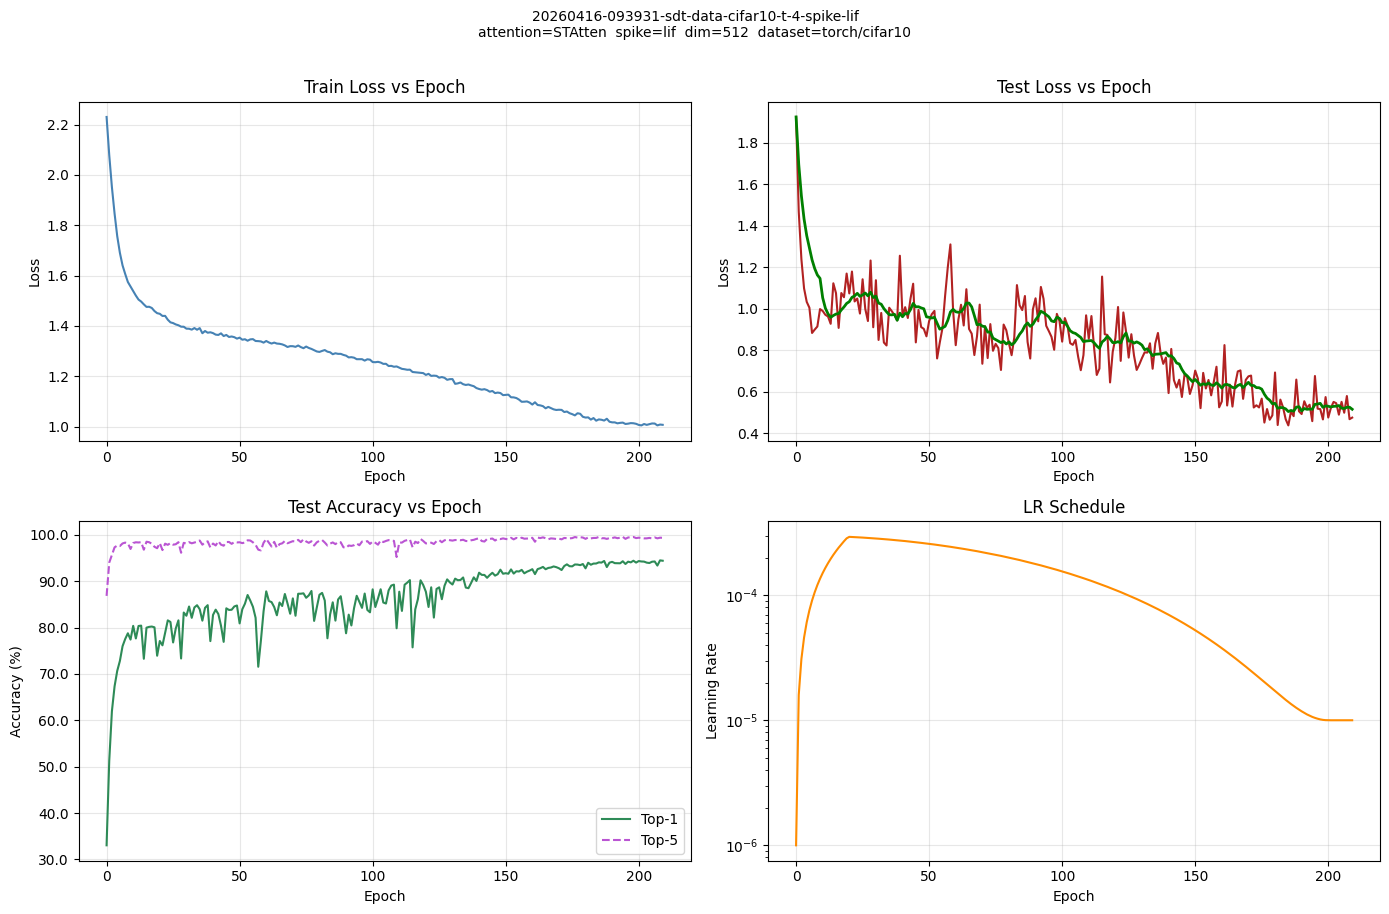

In [10]:
# Plots for currently selected run
# Re-run this cell any time you change the selector above

# Function that produces all desired plots for a specific run (by folder name)
# Name inherited from selector widget, upon re-running plots will be generated for the selected item
def plot_run(run_name):
    if not run_name:
        print("No run selected.")
        return

    args = load_args(run_name)

    # Load from the pre-built CSVs in data/
    safe_name = run_name.replace("/", "_").replace("\\", "_")
    train_csv = os.path.join(DATA_DIR, f"{safe_name}_train.csv")
    test_csv  = os.path.join(DATA_DIR, f"{safe_name}_test.csv")

    if not os.path.exists(train_csv) or not os.path.exists(test_csv):
        print(f"CSVs not found for {run_name} — run the CSV builder cell first.")
        return

    train_df = pd.read_csv(train_csv)
    test_df  = pd.read_csv(test_csv)

    # Merge on epoch for joined plots
    merged = pd.merge(train_df, test_df, on="epoch", how="outer").sort_values("epoch")

    label = (
        f"attention={args.get('attention_mode','?')}  "
        f"spike={args.get('spike_mode','?')}  "
        f"dim={args.get('dim','?')}  "
        f"dataset={args.get('dataset','?')}"
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{run_name}\n{label}", fontsize=10, y=1.01)

    # A: Train loss
    ax = axes[0, 0]
    ax.plot(merged["epoch"], merged["train_loss"], color="steelblue", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Train Loss vs Epoch")
    ax.grid(True, alpha=0.3)

    # B: Test loss
    ax = axes[0, 1]
    ax.plot(merged["epoch"], merged["loss"], color="firebrick", linewidth=1.5)

    # Moving average — window=10, min_periods=1 means it still plots even before
    # 10 epochs have accumulated (it just averages whatever it has so far)
    ma = merged["loss"].rolling(window=10, min_periods=1).mean()
    ax.plot(merged["epoch"], ma, color="green", linewidth=2.0, label="MA (10)")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Test Loss vs Epoch")
    ax.grid(True, alpha=0.3)

    # C: Top-1 and Top-5 accuracy
    ax = axes[1, 0]
    ax.plot(merged["epoch"], merged["acc1"], color="seagreen",     linewidth=1.5, label="Top-1")
    ax.plot(merged["epoch"], merged["acc5"], color="mediumorchid", linewidth=1.5, linestyle="--", label="Top-5")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Test Accuracy vs Epoch")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.legend()
    ax.grid(True, alpha=0.3)

    # D: Learning rate schedule
    ax = axes[1, 1]
    ax.plot(merged["epoch"], merged["lr"], color="darkorange", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_title("LR Schedule")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save PNG to data/ as well
    plot_path = os.path.join(DATA_DIR, f"{safe_name}_plots.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {plot_path}")
    plt.show()

plot_run(selector.value)